In [21]:
import pandas as pd

df = pd.read_csv("Menstruationcycle.csv")

df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17,12,12,...,9,,,2,7,7,1,1,0,21.254724111867
1,nfp8122,2,0,1,0,27,,15,12,13,...,,,,,,,,,,
2,nfp8122,3,0,1,0,29,,15,14,,...,,,,,,,,,,
3,nfp8122,4,0,1,0,27,,15,12,13,...,,,,,,,,,,
4,nfp8122,5,0,1,0,28,,16,12,12,...,,,,,,,,,,


In [22]:

df['Cycle_ID'] = df['ClientID'] + "_" + df['CycleNumber'].astype(str)

df[['ClientID', 'CycleNumber', 'Cycle_ID']].head()

,ClientID,CycleNumber,Cycle_ID
0,nfp8122,1,nfp8122_1
1,nfp8122,2,nfp8122_2
2,nfp8122,3,nfp8122_3
3,nfp8122,4,nfp8122_4
4,nfp8122,5,nfp8122_5


In [23]:
expanded_rows = []

for _, row in df.iterrows():
    cycle_id = row['Cycle_ID']
    length = int(row['LengthofCycle'])

    for day in range(1, length + 1):
        expanded_rows.append({
            'Cycle_ID': cycle_id,
            'Day': day,
            'LengthofCycle': length,
            'EstimatedDayofOvulation': row['EstimatedDayofOvulation']
        })

df_daily = pd.DataFrame(expanded_rows)

df_daily.head()

,Cycle_ID,Day,LengthofCycle,EstimatedDayofOvulation
0,nfp8122_1,1,29,17
1,nfp8122_1,2,29,17
2,nfp8122_1,3,29,17
3,nfp8122_1,4,29,17
4,nfp8122_1,5,29,17


In [24]:
import random

cycle_ids = df_daily['Cycle_ID'].unique()
anov_cycles = set(random.sample(list(cycle_ids), int(0.3 * len(cycle_ids))))

df_daily['Is_Anovulatory'] = df_daily['Cycle_ID'].apply(lambda x: x in anov_cycles)

In [25]:
bbt_values = []

for _, row in df_daily.iterrows():
    day = row['Day']
    ovulation_day = row['EstimatedDayofOvulation']
    is_anov = row['Is_Anovulatory']

    try:
        ovulation_day = int(ovulation_day)
    except:
        ovulation_day = None

    base_temp = np.random.normal(97.3, 0.1)

    if is_anov:

        temp = base_temp + np.random.normal(0, 0.1)
    else:

        if ovulation_day and day >= ovulation_day:
            temp = base_temp + 0.4 + np.random.normal(0, 0.1)
        else:
            temp = base_temp + np.random.normal(0, 0.1)

    bbt_values.append(temp)

df_daily['BBT'] = bbt_values

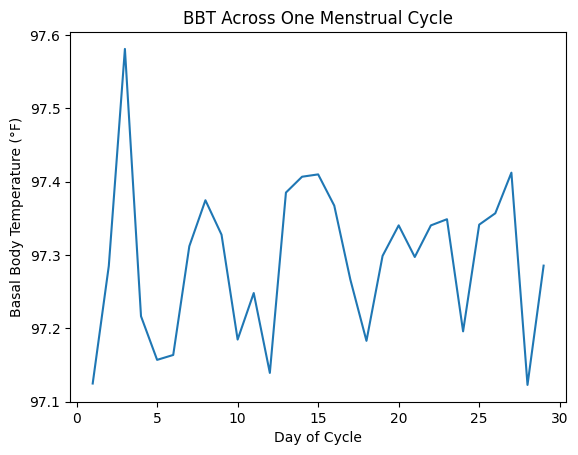

In [26]:
import matplotlib.pyplot as plt


sample_cycle = df_daily[df_daily['Cycle_ID'] == df_daily['Cycle_ID'].iloc[0]]

plt.figure()
plt.plot(sample_cycle['Day'], sample_cycle['BBT'])

plt.xlabel("Day of Cycle")
plt.ylabel("Basal Body Temperature (°F)")
plt.title("BBT Across One Menstrual Cycle")

plt.show()

In [27]:
cycle_results = []


for cycle_id in df_daily['Cycle_ID'].unique():

    cycle_data = df_daily[df_daily['Cycle_ID'] == cycle_id]


    ov_day = cycle_data['EstimatedDayofOvulation'].iloc[0]

    try:
        ov_day = int(ov_day)
    except:
        ov_day = None

    if ov_day:
        before = cycle_data[cycle_data['Day'] < ov_day]['BBT']
        after = cycle_data[cycle_data['Day'] >= ov_day]['BBT']

        if len(before) > 0 and len(after) > 0:
            temp_diff = after.mean() - before.mean()


            ovulatory = temp_diff > 0.2
        else:
            ovulatory = False
    else:
        ovulatory = False

    cycle_results.append({
        'Cycle_ID': cycle_id,
        'Temp_Difference': temp_diff if ov_day else None,
        'Ovulatory': ovulatory
    })

df_results = pd.DataFrame(cycle_results)

df_results.head()

,Cycle_ID,Temp_Difference,Ovulatory
0,nfp8122_1,-0.001201,False
1,nfp8122_2,-0.016754,False
2,nfp8122_3,0.477800,True
3,nfp8122_4,0.355354,True
4,nfp8122_5,0.025054,False


In [28]:
cycle_results = []

for cycle_id in df_daily['Cycle_ID'].unique():

    cycle_data = df_daily[df_daily['Cycle_ID'] == cycle_id]

    ov_day = cycle_data['EstimatedDayofOvulation'].iloc[0]

    try:
        ov_day = int(ov_day)
    except:
        ov_day = None

    if ov_day:
        before = cycle_data[cycle_data['Day'] < ov_day]['BBT']
        after = cycle_data[cycle_data['Day'] >= ov_day]['BBT']

        if len(before) > 0 and len(after) > 0:
            baseline = before.mean()

            elevated_days = sum(after > baseline + 0.2)
            ovulatory = elevated_days >= 3
        else:
            elevated_days = 0
            ovulatory = False
    else:
        elevated_days = 0
        ovulatory = False


    confidence = min(elevated_days / 5, 1)

    cycle_results.append({
        'Cycle_ID': cycle_id,
        'Elevated_Days': elevated_days,
        'Confidence': confidence,
        'Ovulatory': ovulatory
    })

df_results = pd.DataFrame(cycle_results)

df_results.head()

,Cycle_ID,Elevated_Days,Confidence,Ovulatory
0,nfp8122_1,0,0.0,False
1,nfp8122_2,0,0.0,False
2,nfp8122_3,15,1.0,True
3,nfp8122_4,11,1.0,True
4,nfp8122_5,2,0.4,False


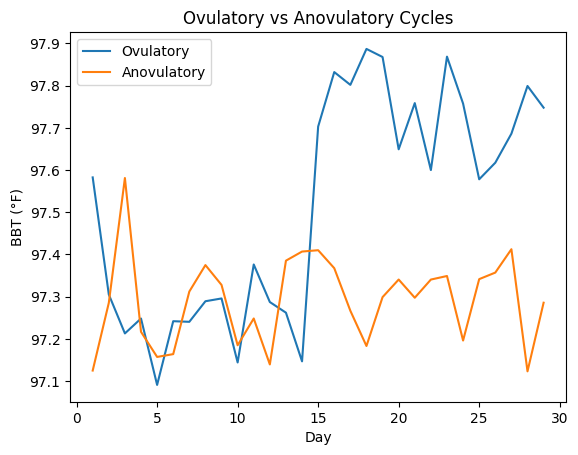

In [29]:
import matplotlib.pyplot as plt

# pick one of each
ov_cycle = df_results[df_results['Ovulatory'] == True]['Cycle_ID'].iloc[0]
anov_cycle = df_results[df_results['Ovulatory'] == False]['Cycle_ID'].iloc[0]

ov_data = df_daily[df_daily['Cycle_ID'] == ov_cycle]
anov_data = df_daily[df_daily['Cycle_ID'] == anov_cycle]

plt.figure()

plt.plot(ov_data['Day'], ov_data['BBT'], label="Ovulatory")
plt.plot(anov_data['Day'], anov_data['BBT'], label="Anovulatory")

plt.xlabel("Day")
plt.ylabel("BBT (°F)")
plt.title("Ovulatory vs Anovulatory Cycles")
plt.legend()

plt.show()